In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
base = "Dino"
threshold = 3.5
attn = 0.7

In [3]:
Comparison = pd.read_csv(f"DC_attn{attn}_Dino.csv")
file_Dino = f"Input Data/ap2_attn_{attn}/ap2_attn_{attn}_centroids.csv"

#Comparison = pd.read_csv(f"Base Output/DetectionComparison.csv")
#file_Dino = "Input Data/attn_0.7/ap2_july22_attn_0.7.csv"
df_Dino = pd.read_csv(file_Dino)
raw = Comparison.copy()
if base == "CME":
    sec = "Dino"
if base == "Dino":
    sec = "CME"

In [4]:
M_comp = Comparison.to_numpy()
t_vec = defaultdict(list)

for t in M_comp:
    t_vec[t[0]].append(t)

for t_val in t_vec:
    t_vec[t_val] = np.array(t_vec[t_val]) 

t_list = np.zeros((len(t_vec),3), dtype=object)

In [5]:
for i, t in enumerate(t_vec):
    t_val = t_vec[t]
    counts = len((t_val[:,11]))
    true_counts = (np.sum(t_val[:,11] < threshold))
    t_list[i][0] = int(t)
    t_list[i][1] = counts
    t_list[i][2] = true_counts

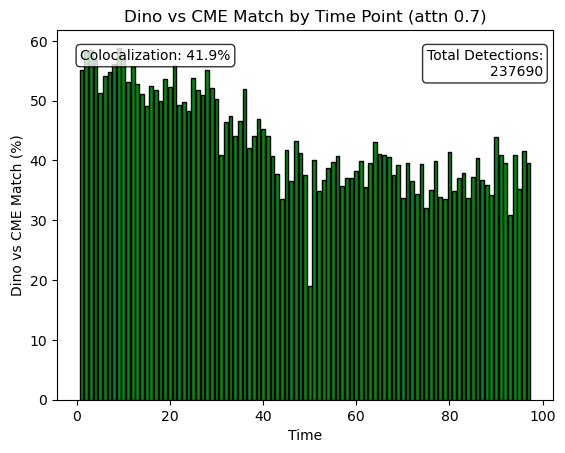

In [6]:
Coloc = round(100*(sum(t_list[:,2]))/(sum(t_list[:,1])),1)
tot_det = len(df_Dino)


fig, ax = plt.subplots()
ax.bar(t_list[:, 0], 100 * t_list[:, 2] / t_list[:, 1], color="#028A0F", edgecolor="black")

ax.text(0.35, 0.95, f'Colocalization: {Coloc}%', 
        transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

ax.text(0.98, 0.95, f'Total Detections:\n{tot_det}', 
        transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

ax.set_xlabel("Time")
ax.set_ylabel(f"{base} vs {sec} Match (%)")
ax.set_title(f"{base} vs {sec} Match by Time Point (attn 0.7)")

plt.savefig("Dino_attn7.png")
plt.show()



In [7]:
"""#Comparison = Comparison[Comparison["t"]==50]

bins = np.linspace(Comparison[f"FI ({base})"].min(), Comparison[f"FI ({base})"].max(), 100)

Comparison[f"FI_bin"] = pd.cut(Comparison[f"FI ({base})"], bins)
total_per_bin = Comparison.groupby("FI_bin",observed =False).size()
matches_per_bin = Comparison[Comparison["Distance"] < threshold].groupby("FI_bin",observed=False).size()
interval_labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]
fraction = (matches_per_bin / total_per_bin).values

plt.figure(figsize=(10, 6))
plt.bar(interval_labels,100*fraction, color = "#028A0F",edgecolor="black")
plt.xlabel(f"FI ({base})")
#plt.xlim(0,10)
plt.xticks(rotation=45, ha="right")
plt.ylabel(f"{base} vs {sec} Match (%)")
plt.title(f"{base} vs {sec} Match by {base} Fluorescence Intensity attn {attn}")
plt.tight_layout()
plt.savefig(f"attn{attn} Match by FI.png")
plt.show()"""


'#Comparison = Comparison[Comparison["t"]==50]\n\nbins = np.linspace(Comparison[f"FI ({base})"].min(), Comparison[f"FI ({base})"].max(), 100)\n\nComparison[f"FI_bin"] = pd.cut(Comparison[f"FI ({base})"], bins)\ntotal_per_bin = Comparison.groupby("FI_bin",observed =False).size()\nmatches_per_bin = Comparison[Comparison["Distance"] < threshold].groupby("FI_bin",observed=False).size()\ninterval_labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]\nfraction = (matches_per_bin / total_per_bin).values\n\nplt.figure(figsize=(10, 6))\nplt.bar(interval_labels,100*fraction, color = "#028A0F",edgecolor="black")\nplt.xlabel(f"FI ({base})")\n#plt.xlim(0,10)\nplt.xticks(rotation=45, ha="right")\nplt.ylabel(f"{base} vs {sec} Match (%)")\nplt.title(f"{base} vs {sec} Match by {base} Fluorescence Intensity attn {attn}")\nplt.tight_layout()\nplt.savefig(f"attn{attn} Match by FI.png")\nplt.show()'

,t,ID (Dino),x (Dino),y (Dino),z (Dino),FI (Dino),ID (CME),x (CME),y (CME),z (CME),FI (CME),Distance,Multi ID (CME),Multi Distance (CME),Multi FI (CME)
0,1.0,0.0,498.72696,343.400400,94.101660,-7.287441e+09,671.0,463.04,341.300,77.7850,242.750,39.296364,NaN,NaN,NaN
1,1.0,1.0,261.02237,14.432339,0.000000,3.261845e+02,5.0,269.17,18.510,2.8182,139.690,9.536952,NaN,NaN,NaN
2,1.0,2.0,259.69870,30.781248,0.565429,3.011901e+03,40.0,271.78,29.509,5.4171,117.790,13.081099,NaN,NaN,NaN
3,1.0,3.0,261.40082,63.190243,1.849812,2.193914e+04,16.0,269.82,49.481,4.2725,242.750,16.269461,NaN,NaN,NaN
4,1.0,4.0,265.04514,74.257880,1.694314,7.708925e+03,66.0,272.91,76.609,7.6123,359.230,10.119602,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237685,97.0,2144.0,548.76160,702.998600,166.999680,-7.391611e+01,1399.0,544.77,701.820,156.9600,84.266,10.868171,NaN,NaN,NaN
237686,97.0,2145.0,627.91960,702.999100,165.988430,2.701241e+02,1491.0,563.47,681.590,163.5200,229.490,67.957293,NaN,NaN,NaN
237687,97.0,2146.0,651.61040,702.996150,166.999100,6.006207e+01,1491.0,563.47,681.590,163.5200,229.490,90.769254,NaN,NaN,NaN
237688,97.0,2147.0,666.98320,702.982300,166.995800,1.540314e+01,1491.0,563.47,681.590,163.5200,229.490,105.757715,NaN,NaN,NaN


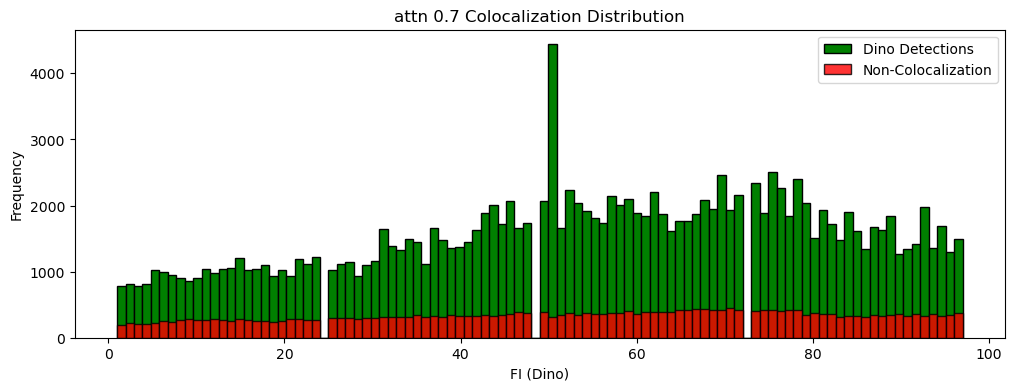

In [8]:
Comparison = pd.read_csv(f"DC_attn{attn}_Dino.csv")
display(Comparison[Comparison["Distance"] > threshold])
#Comparison = Comparison[Comparison["t"]==45]

Comparison = Comparison[Comparison["FI (Dino)"]>-500]
Comparison = Comparison[Comparison["FI (Dino)"]<5000]
Comp_coloc = Comparison[Comparison["Distance"] < threshold]

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.hist(Comparison["t"], bins=100, color="green", label=f"Dino Detections", edgecolor="black")
ax.hist(Comp_coloc["t"], bins=100, color="red", alpha=0.8, label=f"Non-Colocalization", edgecolor="black")
ax.set_xlabel("FI (Dino)")
ax.set_ylabel("Frequency")
ax.set_title(f"attn {attn} Colocalization Distribution")
ax.legend()

#plt.savefig(f"attn{attn}.png")
plt.show()

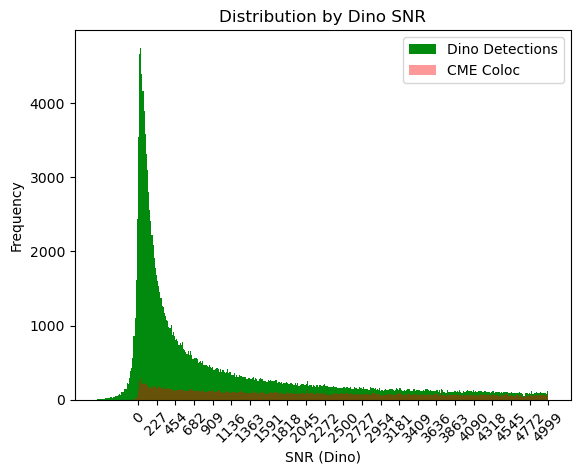

In [9]:
Comp_SNR = Comparison.copy()
Comp_SNR["FI (CME)"] = Comp_SNR["FI (CME)"]/31
SNR_coloc = Comp_SNR[Comp_SNR["Distance"]<3.5]

all_values = pd.concat([
    Comp_SNR[f"FI ({base})"],
    SNR_coloc[f"FI ({base})"]
])

bins = np.linspace(all_values.min(), all_values.max(), 401)

plt.hist(Comp_SNR[f"FI ({base})"], bins=bins, color="#028A0F", label=f"{base} Detections")
plt.hist(SNR_coloc[f"FI ({base})"], bins=bins, color="red", alpha=0.4, label=f"{sec} Coloc")
plt.xlabel(f"SNR ({base})")
plt.ylabel("Frequency")
plt.title(f"Distribution by {base} SNR")
plt.xticks(np.linspace(0, max(Comp_SNR[f"FI ({base})"]), 23), rotation=45)
plt.legend()
plt.show()

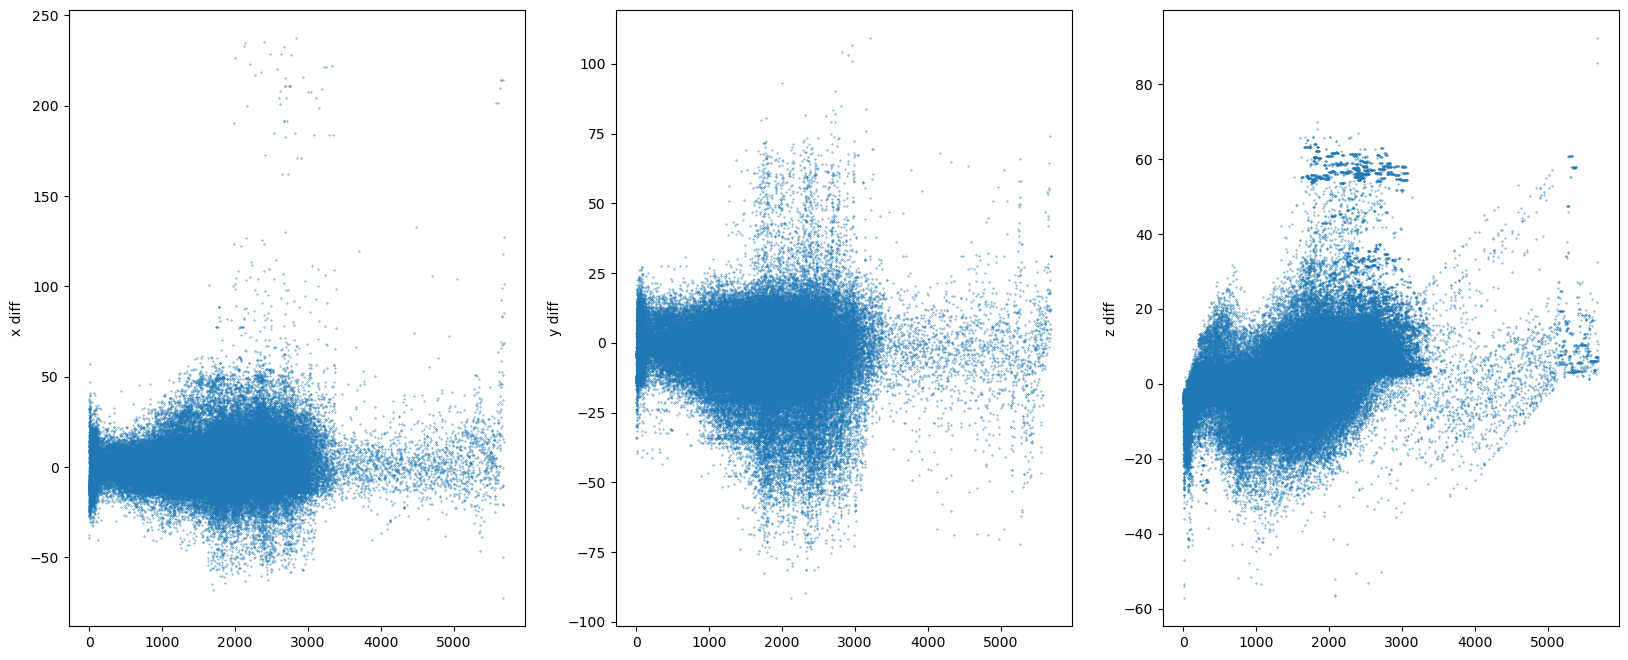

In [10]:
Comp_SNR_non = Comp_SNR[Comp_SNR["Distance"]>3.5]
xdiff = Comp_SNR_non[f"x ({base})"]-Comp_SNR_non[f"x ({sec})"]
ydiff = Comp_SNR_non[f"y ({base})"]-Comp_SNR_non[f"y ({sec})"]
zdiff = Comp_SNR_non[f"z ({base})"]-Comp_SNR_non[f"z ({sec})"]

fig = plt.figure(figsize=(20,8))
plt.subplot(1,3,1)
plt.scatter(Comp_SNR_non[f"ID ({base})"],xdiff, s=0.1)
plt.ylabel("x diff")
plt.subplot(1,3,2)
plt.scatter(Comp_SNR_non[f"ID ({base})"],ydiff,s=0.1)
plt.ylabel("y diff")
plt.subplot(1,3,3)
plt.scatter(Comp_SNR_non[f"ID ({base})"],zdiff,s=0.1)
plt.ylabel("z diff")
plt.show()

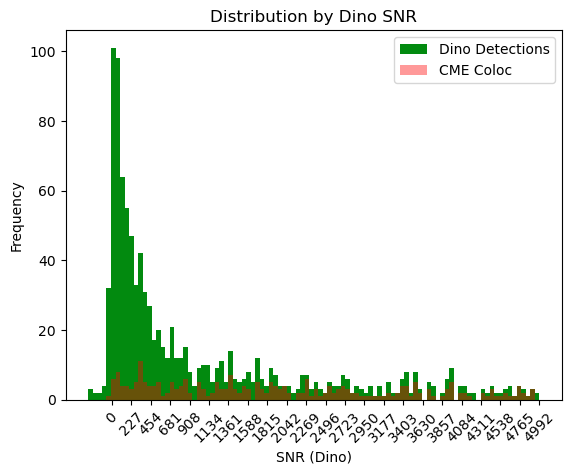

In [11]:
time = 20

Comp_SNR_time = Comp_SNR[Comp_SNR["t"]==time]
Coloc_SNR_time = Comp_SNR_time[Comp_SNR_time["Distance"]<3.5]

all_values = pd.concat([
    Comp_SNR_time[f"FI ({base})"],
    Coloc_SNR_time[f"FI ({base})"]
])

bins = np.linspace(all_values.min(), all_values.max(), 101)

plt.hist(Comp_SNR_time[f"FI ({base})"], bins=bins, color="#028A0F", label=f"{base} Detections")
plt.hist(Coloc_SNR_time[f"FI ({base})"], bins=bins, color="red", alpha=0.4, label=f"{sec} Coloc")
plt.xlabel(f"SNR ({base})")
plt.ylabel("Frequency")
plt.title(f"Distribution by {base} SNR")
plt.xticks(np.linspace(0, max(Comp_SNR_time[f"FI ({base})"]), 23), rotation=45)
plt.legend()
plt.show()

In [12]:
display(raw)

,t,ID (Dino),x (Dino),y (Dino),z (Dino),FI (Dino),ID (CME),x (CME),y (CME),z (CME),FI (CME),Distance,Multi ID (CME),Multi Distance (CME),Multi FI (CME)
0,1.0,0.0,498.72696,343.400400,94.101660,-7.287441e+09,671.0,463.04,341.300,77.7850,242.750,39.296364,NaN,NaN,NaN
1,1.0,1.0,261.02237,14.432339,0.000000,3.261845e+02,5.0,269.17,18.510,2.8182,139.690,9.536952,NaN,NaN,NaN
2,1.0,2.0,259.69870,30.781248,0.565429,3.011901e+03,40.0,271.78,29.509,5.4171,117.790,13.081099,NaN,NaN,NaN
3,1.0,3.0,261.40082,63.190243,1.849812,2.193914e+04,16.0,269.82,49.481,4.2725,242.750,16.269461,NaN,NaN,NaN
4,1.0,4.0,265.04514,74.257880,1.694314,7.708925e+03,66.0,272.91,76.609,7.6123,359.230,10.119602,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237685,97.0,2144.0,548.76160,702.998600,166.999680,-7.391611e+01,1399.0,544.77,701.820,156.9600,84.266,10.868171,NaN,NaN,NaN
237686,97.0,2145.0,627.91960,702.999100,165.988430,2.701241e+02,1491.0,563.47,681.590,163.5200,229.490,67.957293,NaN,NaN,NaN
237687,97.0,2146.0,651.61040,702.996150,166.999100,6.006207e+01,1491.0,563.47,681.590,163.5200,229.490,90.769254,NaN,NaN,NaN
237688,97.0,2147.0,666.98320,702.982300,166.995800,1.540314e+01,1491.0,563.47,681.590,163.5200,229.490,105.757715,NaN,NaN,NaN


In [13]:
col = raw[raw["Distance"]<=threshold]
non_col = raw[raw["Distance"]>threshold]

In [14]:
plt.figure(figsize=(20,6))

all_values0 = pd.concat([
    raw[f"Feature 0"],
    col[f"Feature 0"]
])

bins = np.linspace(all_values0.min(), all_values0.max(), 51)
plt.subplot(1,3,1)
plt.hist(raw[f"Feature 0"], bins=bins, color="#028A0F", label=f"{base} Detections")
plt.hist(col[f"Feature 0"], bins=bins, color="red", alpha=0.4, label=f"{sec} Coloc")
plt.xlabel(f"Feature 0")
plt.ylabel("Frequency")
plt.title(f"Distribution by Feature 0")
plt.xticks(np.linspace(min(raw[f"Feature 0"]), max(raw[f"Feature 0"]), 23), rotation=45)
plt.legend()

all_values1 = pd.concat([
    raw[f"Feature 1"],
    col[f"Feature 1"]
])

bins = np.linspace(all_values1.min(), all_values1.max(), 51)
plt.subplot(1,3,2)
plt.hist(raw[f"Feature 1"], bins=bins, color="#028A0F", label=f"{base} Detections")
plt.hist(col[f"Feature 1"], bins=bins, color="red", alpha=0.4, label=f"{sec} Coloc")
plt.xlabel(f"Feature 1")
plt.ylabel("Frequency")
plt.title(f"Distribution by Feature 1")
plt.xticks(np.linspace(min(raw[f"Feature 1"]), max(raw[f"Feature 1"]), 23), rotation=45)
plt.legend()

all_values2 = pd.concat([
    raw[f"Feature 2"],
    col[f"Feature 2"]
])

bins = np.linspace(all_values2.min(), all_values2.max(), 51)
plt.subplot(1,3,3)
plt.hist(raw[f"Feature 2"], bins=bins, color="#028A0F", label=f"{base} Detections")
plt.hist(col[f"Feature 2"], bins=bins, color="red", alpha=0.4, label=f"{sec} Coloc")
plt.xlabel(f"Feature 2")
plt.ylabel("Frequency")
plt.title(f"Distribution by Feature 2")
plt.xticks(np.linspace(min(raw[f"Feature 2"]), max(raw[f"Feature 2"]), 23), rotation=45)
plt.legend()

plt.show()

KeyError: 'Feature 0'

<Figure size 2000x600 with 0 Axes>

In [ ]:
check = raw[raw["ID (CME)"]==491]

plt.subplot(1,3,1)
plt.plot(check["t"], check["Feature 0"])